In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train = pd.read_csv('/content/train.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Titanic 데이터 분석

## 1. 데이터 불러오기
Titanic 승객 데이터를 불러오고 데이터의 전체적인 구조를 확인한다.

In [4]:
# 데이터의 행과 열 개수를 확인한다.
train.shape

(891, 12)

In [5]:
# 각 컬럼의 이름과 데이터 타입, 결측치 여부 등을 확인한다.
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# 수치형 데이터의 기본적인 통계값을 확인한다.
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2. 데이터 확인

데이터의 크기와 컬럼, 데이터 타입 등을 확인한다.

Titanic 데이터에는 승객의 성별, 나이, 객실 등급, 요금 등의 정보가 있으며
Survived 컬럼을 통해 생존 여부를 확인할 수 있다.

In [7]:
# 각 컬럼에 존재하는 결측치의 개수를 확인한다.
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### 결측치 확인

Age, Cabin, Embarked 등의 컬럼에 결측치가 존재하는 것을 확인할 수 있다.

따라서 이후 전처리 과정에서 결측치를 처리할 필요가 있다.

In [8]:
# 생존 여부에 따른 승객 수를 확인한다.
# 0은 사망, 1은 생존을 의미한다.
train['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [9]:
# 전체 승객의 평균 생존율을 확인한다.
train['Survived'].mean()

np.float64(0.3838383838383838)

## 3. 탐색적 데이터 분석(EDA)

Survived는 0과 1로 구성되어 있으며,
0은 사망한 승객, 1은 생존한 승객을 의미한다.

전체 승객 중 생존한 승객과 사망한 승객의 비율을 확인하였다.

In [10]:
# 성별에 따른 평균 생존율을 확인한다.
train.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


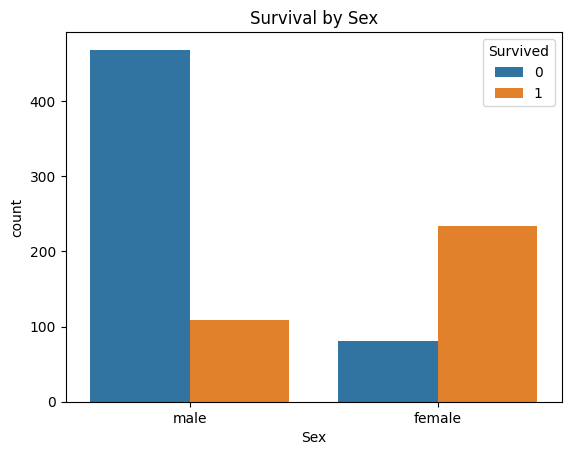

In [11]:
# 성별과 생존 여부의 관계를 시각화한다.
sns.countplot(data=train, x='Sex', hue='Survived')

plt.title('Survival by Sex')
plt.show()

### 성별과 생존 여부

그래프를 확인한 결과 여성 승객의 생존 비율이 남성 승객보다 높은 것을 확인할 수 있다.

따라서 성별은 생존 여부와 관련이 있는 중요한 특징이라고 생각할 수 있다.

In [12]:
# 객실 등급(Pclass)에 따른 생존율을 확인한다.
train.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


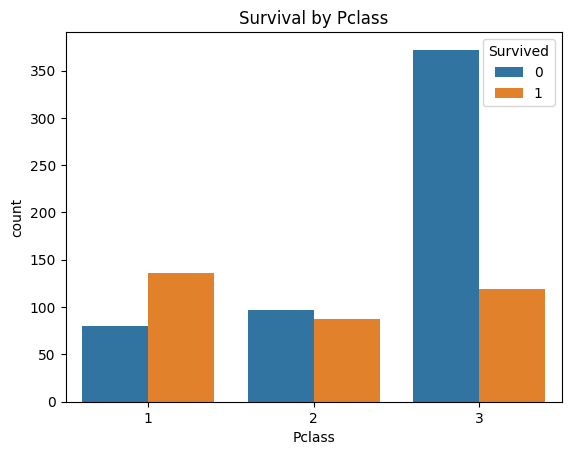

In [13]:
# 객실 등급과 생존 여부를 시각화한다.
sns.countplot(data=train, x='Pclass', hue='Survived')

plt.title('Survival by Pclass')
plt.show()

### 객실 등급과 생존 여부

1등급 객실 승객의 생존율이 상대적으로 높고,
3등급 객실 승객의 생존율이 낮은 것을 확인할 수 있다.

따라서 객실 등급도 생존 여부와 관계가 있음을 알 수 있다.

In [ ]:
# 승객들의 나이 분포와 생존 여부를 함께 확인한다.
sns.histplot(data=train, x='Age', hue='Survived', kde=True)

plt.title('Age Distribution by Survival')
plt.show()

### 나이와 생존 여부

승객의 나이에 따라 생존자와 사망자의 분포가 어떻게 다른지 확인하였다.

나이 정보에는 결측치가 있기 때문에 이후 전처리 과정에서 결측치를 채워줄 필요가 있다.

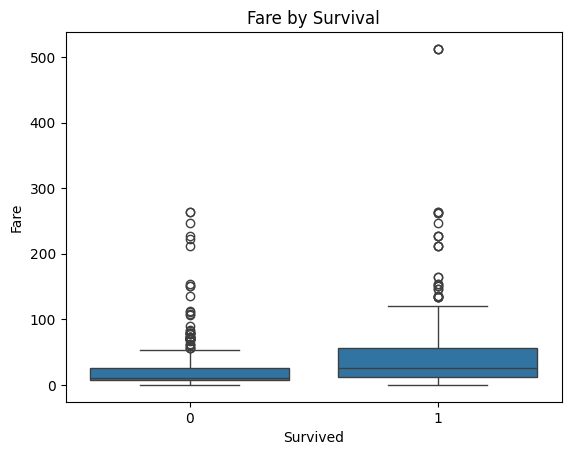

In [14]:
# 생존 여부에 따른 승객들의 요금 분포를 확인한다.
sns.boxplot(data=train, x='Survived', y='Fare')

plt.title('Fare by Survival')
plt.show()

### 요금과 생존 여부

생존 여부에 따라 승객들이 지불한 요금의 분포에 차이가 있음을 확인할 수 있다.

높은 객실 등급의 승객이 비교적 높은 요금을 지불했을 가능성이 있기 때문에
Pclass와 함께 살펴볼 필요가 있다.

In [15]:
# 원본 데이터를 보존하기 위해 새로운 데이터프레임을 만든다.
df = train.copy()

In [16]:
# Age의 결측치를 나이의 중앙값으로 채운다.
# 중앙값은 극단적인 값의 영향을 평균보다 적게 받는다.
df['Age'] = df['Age'].fillna(df['Age'].median())

In [17]:
# Embarked는 범주형 데이터이므로
# 가장 많이 등장하는 값(mode)으로 결측치를 채운다.
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [18]:
# Cabin은 결측치의 비율이 매우 높기 때문에 삭제한다.
df = df.drop(columns=['Cabin'])

In [19]:
# 결측치가 잘 처리되었는지 다시 확인한다.
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [20]:
# SibSp는 함께 탑승한 형제/배우자 수,
# Parch는 함께 탑승한 부모/자녀 수를 의미한다.
# 여기에 본인 1명을 더해 전체 가족 수를 계산한다.

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [21]:
# FamilySize가 1이면 혼자 탑승한 것으로 판단한다.
# 혼자이면 1, 가족과 함께라면 0으로 표현한다.

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df[['FamilySize', 'IsAlone']].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


In [22]:
# 승객 이름에서 Mr, Mrs, Miss, Master 등의 호칭을 추출한다.
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# 어떤 호칭들이 있는지 확인한다.
df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


## 4. 전처리 및 특징값 생성

Age의 결측치는 중앙값으로 처리하고,
Embarked의 결측치는 가장 많이 등장하는 값으로 처리하였다.

Cabin은 결측치가 너무 많아 분석에서 제외하였다.

또한 기존 데이터를 이용하여 FamilySize와 IsAlone이라는 새로운 특징을 생성하였다.

Name 컬럼에서는 Mr, Mrs, Miss 등의 호칭을 추출하여 Title이라는 새로운 특징을 생성하였다.

In [23]:
# 머신러닝에서는 문자열 데이터를 그대로 사용할 수 없기 때문에
# 남성은 0, 여성은 1로 변환한다.

df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

df[['Sex']].head()

,Sex
0,0
1,1
2,1
3,1
4,0


In [24]:
# Embarked는 여러 개의 범주를 가지고 있기 때문에
# One-Hot Encoding을 사용하여 숫자 형태로 변환한다.

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [25]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,FamilySize,IsAlone,Title,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,2,0,Mr,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,2,0,Mrs,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,1,1,Miss,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,2,0,Mrs,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,1,1,Mr,False,True


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  FamilySize   891 non-null    int64  
 11  IsAlone      891 non-null    int64  
 12  Title        891 non-null    object 
 13  Embarked_Q   891 non-null    bool   
 14  Embarked_S   891 non-null    bool   
dtypes: bool(2), float64(2), int64(8), object(3)
memory usage: 92.4+ KB


## 5. 정리

이번 분석에서는 Titanic 데이터를 이용하여 데이터의 구조와 결측치를 확인하고,
성별, 객실 등급, 나이, 요금 등에 따른 생존 여부를 탐색하였다.

분석 결과 성별과 객실 등급에 따라 생존율에 차이가 있음을 확인하였다.

이후 Age와 Embarked의 결측치를 처리하고,
FamilySize, IsAlone, Title과 같은 새로운 특징을 생성하였다.

또한 문자열 형태의 범주형 데이터를 숫자로 변환하여
향후 모델 학습에 사용할 수 있는 형태로 전처리하였다.